# Datathon FIAP — Passos Mágicos
## Modelo preditivo de risco de defasagem escolar

**Objetivo (pergunta 9 do Datathon):** identificar padrões nos indicadores do PEDE que permitam antecipar alunos em risco, estimando a **probabilidade de o aluno estar em defasagem escolar no ano seguinte**.

**Estratégia:** como temos 3 anos de PEDE (2022, 2023, 2024) com o `RA` como identificador, montamos pares longitudinais — indicadores do aluno no ano *t* como features, situação de defasagem no ano *t+1* como alvo. Isso dá ao modelo caráter genuinamente **preditivo** (e não apenas descritivo).

Etapas: **1)** limpeza e feature engineering · **2)** separação treino/teste (validação temporal) · **3)** modelagem · **4)** avaliação.

In [1]:
import re, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
import joblib

RANDOM_STATE = 42
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Limpeza e feature engineering

Principais tratamentos:
- **Fase** vem em formato diferente a cada ano (`7`, `FASE 7`, `7A`, `ALFA`) → extraímos a fase numérica (ALFA = 0);
- **INDE 2024** contém o texto `INCLUIR` para alunos sem avaliação → convertido para `NaN`;
- **Pedra** com grafias inconsistentes (`Agata`/`Ágata`) → padronizada;
- A aba 2022 **não traz IPP** → reconstruímos pela fórmula oficial do INDE (fases 0–7): `INDE = 0,1·IAN + 0,2·IDA + 0,2·IEG + 0,1·IAA + 0,1·IPS + 0,1·IPP + 0,2·IPV`;
- Criamos `anos_na_pm` (tempo de casa) e `genero_fem`.

In [2]:
ARQ = 'BASE_DE_DADOS_PEDE_2024_-_DATATHON.xlsx'

def norm_pedra(x):
    if pd.isna(x): return np.nan
    x = unicodedata.normalize('NFKD', str(x).strip().title()).encode('ascii','ignore').decode()
    return {'Agata':'Ágata','Ametista':'Ametista','Topazio':'Topázio','Quartzo':'Quartzo'}.get(x, np.nan)

def extrai_fase(x):
    x = str(x).strip().upper()
    if x == 'ALFA': return 0
    m = re.search(r'(\d)', x)
    return int(m.group(1)) if m else np.nan

def to_num(s): return pd.to_numeric(s, errors='coerce')

def monta_ano(df, ano, cmap):
    out = pd.DataFrame({'RA': df['RA'], 'ano': ano})
    out['fase'] = df[cmap['fase']].apply(extrai_fase)
    out['genero'] = df['Gênero'].replace({'Menina':'Feminino','Menino':'Masculino'})
    out['idade'] = to_num(df[cmap['idade']])
    out['anos_na_pm'] = ano - to_num(df['Ano ingresso'])
    for k in ['IAA','IEG','IPS','IDA','IPV','IAN']:
        out[k] = to_num(df[k])
    out['IPP'] = to_num(df['IPP']) if 'IPP' in df.columns else np.nan
    out['INDE'] = to_num(df[cmap['inde']])
    out['nota_mat'] = to_num(df[cmap['mat']]); out['nota_por'] = to_num(df[cmap['por']]); out['nota_ing'] = to_num(df[cmap['ing']])
    out['defasagem'] = to_num(df[cmap['defas']])
    return out

xl = pd.ExcelFile(ARQ)
p22 = monta_ano(xl.parse('PEDE2022'), 2022, dict(fase='Fase', idade='Idade 22', inde='INDE 22', mat='Matem', por='Portug', ing='Inglês', defas='Defas'))
p23 = monta_ano(xl.parse('PEDE2023'), 2023, dict(fase='Fase', idade='Idade', inde='INDE 2023', mat='Mat', por='Por', ing='Ing', defas='Defasagem'))
p24 = monta_ano(xl.parse('PEDE2024'), 2024, dict(fase='Fase', idade='Idade', inde='INDE 2024', mat='Mat', por='Por', ing='Ing', defas='Defasagem'))

# IPP de 2022 reconstruído pela fórmula do INDE
m = p22['fase'] <= 7
rec = (p22['INDE'] - (0.1*p22['IAN'] + 0.2*p22['IDA'] + 0.2*p22['IEG'] + 0.1*p22['IAA'] + 0.1*p22['IPS'] + 0.2*p22['IPV'])) / 0.1
p22.loc[m, 'IPP'] = rec[m].clip(0, 10).round(3)

panel = pd.concat([p22, p23, p24], ignore_index=True)
panel.groupby('ano')[['INDE','IDA','IEG','IAN','defasagem']].mean().round(3)

,INDE,IDA,IEG,IAN,defasagem
ano,,,,,
2022,7.036,6.093,7.891,6.424,-0.943
2023,7.342,6.663,8.699,7.244,-0.655
2024,7.397,6.351,7.375,7.684,-0.409


### Pares longitudinais e variável-alvo

Ligamos cada aluno pelo `RA` entre anos consecutivos (2022→2023 e 2023→2024).

**Alvo:** `risco = 1` se `defasagem < 0` no ano seguinte (aluno atrás da fase ideal).

In [3]:
pares = []
for a0, a1 in [(2022, 2023), (2023, 2024)]:
    mrg = panel[panel.ano==a0].merge(panel[panel.ano==a1], on='RA', suffixes=('_t','_t1'))
    pares.append(mrg)
pares = pd.concat(pares, ignore_index=True)

valid = pares.dropna(subset=['defasagem_t1','defasagem_t','INDE_t']).copy()
valid['risco'] = (valid['defasagem_t1'] < 0).astype(int)
valid['genero_fem'] = (valid['genero_t']=='Feminino').astype(int)

FEATURES = ['IAA_t','IEG_t','IPS_t','IPP_t','IDA_t','IPV_t','IAN_t','INDE_t','defasagem_t',
            'fase_t','idade_t','anos_na_pm_t','nota_mat_t','nota_por_t','nota_ing_t','genero_fem']
X, y = valid[FEATURES], valid['risco']
print(f'Pares válidos: {len(valid)} | taxa de risco: {y.mean():.1%}')
valid.groupby('ano_t')['risco'].agg(['count','mean']).round(3)

Pares válidos: 1290 | taxa de risco: 52.0%


,count,mean
ano_t,,
2022,600,0.610
2023,690,0.442


## 2. Separação treino/teste — validação temporal

Para simular o uso real (prever o futuro com dados do passado), treinamos com os pares **2022→2023** e testamos nos pares **2023→2024**. Nenhuma informação do ano de teste vaza para o treino.

In [4]:
tr = (valid['ano_t']==2022).values
te = (valid['ano_t']==2023).values
X_tr, y_tr, X_te, y_te = X[tr], y[tr], X[te], y[te]
print(f'Treino (2022→23): {tr.sum()} alunos | Teste (2023→24): {te.sum()} alunos')

Treino (2022→23): 600 alunos | Teste (2023→24): 690 alunos


## 3. Modelagem

Usamos **HistGradientBoostingClassifier** (gradient boosting do scikit-learn): lida nativamente com valores ausentes (frequentes na base, ex.: nota de inglês), captura não linearidades e interações entre indicadores, e é robusto sem exigir normalização. Comparamos com uma **regressão logística** como baseline.

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

baseline = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                         LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
baseline.fit(X_tr, y_tr)
p_base = baseline.predict_proba(X_te)[:,1]

modelo = HistGradientBoostingClassifier(max_iter=400, learning_rate=0.06, max_depth=4,
                                        l2_regularization=1.0, random_state=RANDOM_STATE)
modelo.fit(X_tr, y_tr)
p_hgb = modelo.predict_proba(X_te)[:,1]

print(f'Baseline (Reg. Logística) — AUC: {roc_auc_score(y_te, p_base):.3f}')
print(f'Gradient Boosting        — AUC: {roc_auc_score(y_te, p_hgb):.3f} | AP: {average_precision_score(y_te, p_hgb):.3f}')

Baseline (Reg. Logística) — AUC: 0.787
Gradient Boosting        — AUC: 0.845 | AP: 0.814


## 4. Avaliação

              precision    recall  f1-score   support

   Sem risco      0.744     0.870     0.802       385
    Em risco      0.792     0.623     0.697       305

    accuracy                          0.761       690
   macro avg      0.768     0.747     0.750       690
weighted avg      0.765     0.761     0.756       690



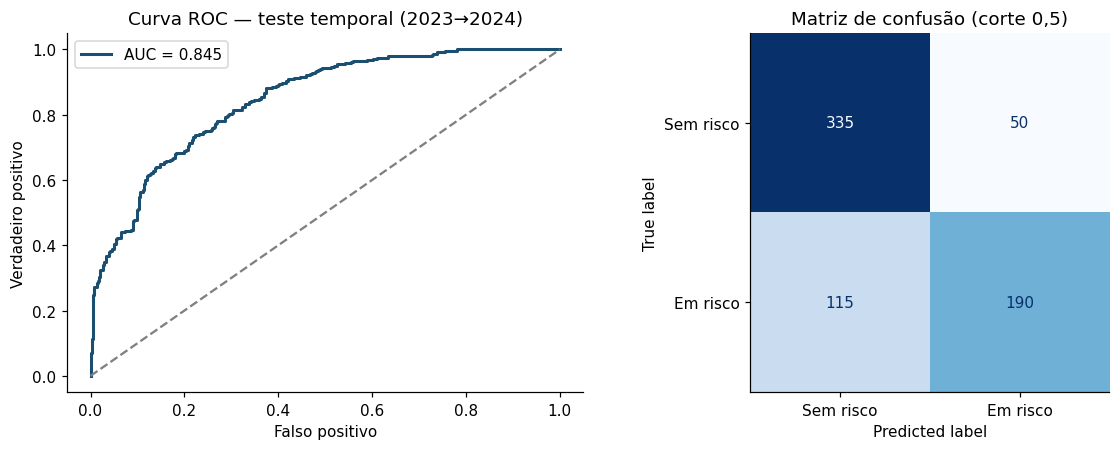

In [6]:
print(classification_report(y_te, (p_hgb>=0.5).astype(int), target_names=['Sem risco','Em risco'], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
fpr, tpr, _ = roc_curve(y_te, p_hgb)
axes[0].plot(fpr, tpr, lw=2, color='#1B4F72', label=f'AUC = {roc_auc_score(y_te,p_hgb):.3f}')
axes[0].plot([0,1],[0,1],'--', color='gray')
axes[0].set_xlabel('Falso positivo'); axes[0].set_ylabel('Verdadeiro positivo')
axes[0].set_title('Curva ROC — teste temporal (2023→2024)'); axes[0].legend()
ConfusionMatrixDisplay(confusion_matrix(y_te, (p_hgb>=0.5).astype(int)),
                       display_labels=['Sem risco','Em risco']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de confusão (corte 0,5)')
plt.tight_layout(); plt.show()

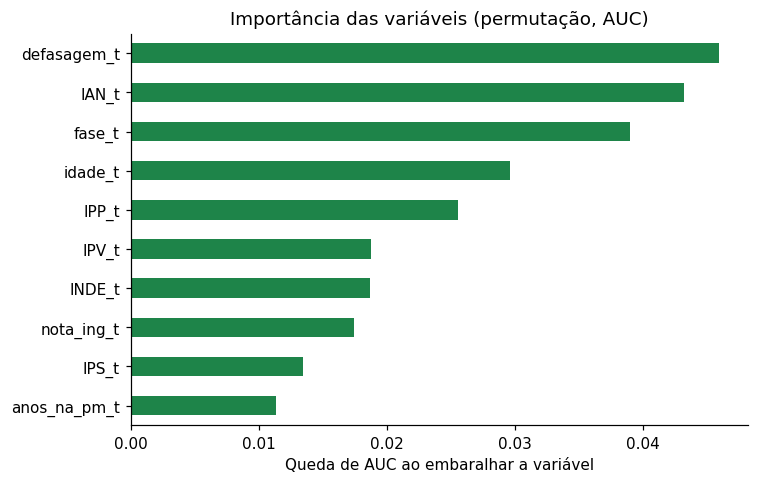

defasagem_t    0.0459
IAN_t          0.0432
fase_t         0.0390
idade_t        0.0296
IPP_t          0.0256
IPV_t          0.0187
INDE_t         0.0187
nota_ing_t     0.0175
dtype: float64

In [7]:
r = permutation_importance(modelo, X_te, y_te, n_repeats=15, random_state=RANDOM_STATE, scoring='roc_auc')
imp = pd.Series(r.importances_mean, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7,4.5))
imp.tail(10).plot.barh(ax=ax, color='#1E8449')
ax.set_title('Importância das variáveis (permutação, AUC)')
ax.set_xlabel('Queda de AUC ao embaralhar a variável')
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(4).head(8)

**Leitura dos resultados:**
- AUC ≈ **0,84** em validação temporal: o modelo ordena bem quem estará defasado no ano seguinte usando apenas os indicadores do ano corrente.
- As variáveis mais importantes são **defasagem atual, IAN, fase e idade** (a defasagem é persistente — quem já está atrás tende a continuar sem intervenção), seguidas de **IPP, IPV e INDE**.
- Com corte 0,5, o modelo captura ~62% dos alunos que estarão em risco com ~79% de precisão. O corte pode ser reduzido para priorizar *recall* (encontrar mais alunos em risco), a depender da capacidade de atendimento das equipes.

## 5. Modelo final para produção

Para o app Streamlit, treinamos com **todos os pares** (2022→23 + 2023→24) e calibramos as probabilidades (isotonic, CV=5), para que a probabilidade exibida às equipes da Passos Mágicos seja interpretável.

In [8]:
final = CalibratedClassifierCV(
    HistGradientBoostingClassifier(max_iter=400, learning_rate=0.06, max_depth=4,
                                   l2_regularization=1.0, random_state=RANDOM_STATE),
    cv=5, method='isotonic')
final.fit(X, y)
joblib.dump({'model': final, 'features': FEATURES,
             'auc_temporal': float(roc_auc_score(y_te, p_hgb))}, 'modelo_risco.joblib')
print('Modelo salvo em modelo_risco.joblib')

Modelo salvo em modelo_risco.joblib
